In [4]:
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.io import fits
from astropy.wcs import WCS
from spectral_cube import SpectralCube

import warnings
warnings.filterwarnings('ignore', message='.*PV2_1.*')
warnings.filterwarnings('ignore', message='.*PV2_2.*')
warnings.filterwarnings('ignore', message='.*TIMESYS.*')


In [ ]:
cubefile = 'test_data/HLTAU_HCOp32.fits'  # Replace with actual path

from velocity_tools import extract_streamline


# get the spectralcube object from the data using spectral-cube
hdu = fits.open(cubefile)[0]
cube = SpectralCube.read(hdu).with_spectral_unit(u.km/u.s, rest_value=hdu.header['RESTFRQ']*u.Hz)
print("Loaded cube with shape:", cube.shape)

# TODO: this streamer extraction should be replaced with clustering-based streamer extraction

# extract the subcube with the streamer (we got this from the tipsy tutorial, no need to plot)
## Limits for extracting subcube with streamer
vmin = 7    # Min. vel. of streamer
vmax = 10
xmin = -3   # Min R.A. offset to consider for streamer
xmax = -1
ymin = -3   # Min. Decl. offset to consider for stremar
ymax = 0.5
rms_thresh = 4  # sigma threshold for streamer

# extract the streamer subcube
info_header = cube.header  # header of the cube, contains required information
x_conv_fac = 1/60/60/info_header['CDELT1']
xmin_p = int((xmin*x_conv_fac)+info_header['CRPIX1'])
xmax_p = int((xmax*x_conv_fac)+info_header['CRPIX1'])
y_conv_fac = 1/60/60/info_header['CDELT2']
ymin_p = int((ymin*y_conv_fac)+info_header['CRPIX2'])
ymax_p = int((ymax*y_conv_fac)+info_header['CRPIX2'])
vunit = cube.spectral_axis.unit
## Note: a check can be added to see if requested limits are within the limits of the cube itself

streamer_cubev = cube.spectral_slab(vmin*vunit,vmax*vunit)    # Selecting velocities
streamer_cubevc = streamer_cubev[:,min(ymin_p,ymax_p):max(ymin_p,ymax_p)   
                    ,min(xmin_p,xmax_p):max(xmin_p,xmax_p)]   # Selecting pixels
#     print(min(ymin_p,ymax_p),max(ymin_p,ymax_p),min(xmin_p,xmax_p),max(xmin_p,xmax_p)) 
streamer_cube = streamer_cubevc.with_mask(streamer_cubevc > rms_thresh*streamer_cubevc.mad_std())  # Removing low flux values 


Loaded cube with shape: (500, 401, 401)


In [6]:

# Extract 1D streamline from the data cube
pc_coords, pc_means, pc_stds = extract_streamline.reduce_to_1D(streamer_cube, n_elements=10)

Starting reduction
Created coordinate arrays
Got point cloud with 14974 points
Partition boundaries for projected distance metric: [1.031 1.122 1.176 1.234 1.3   1.383 1.48  1.602 1.732 1.898 3.251]


Text(0.5, 1.0, 'Extracted 1D Streamer emission')

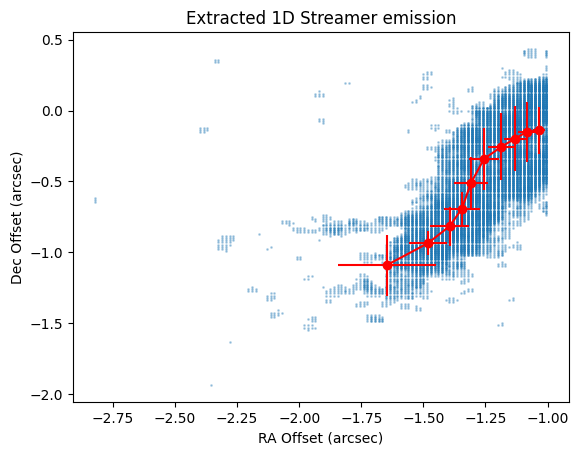

In [8]:
# plot it
import matplotlib.pyplot as plt
# plot the observed data points as a scatter
plt.scatter(pc_coords[0], pc_coords[1], s=1, alpha=0.3, label='Point cloud')
# plot the extracted 1D streamline with error bars
plt.errorbar(pc_means[0], pc_means[1], xerr=pc_stds[0], yerr=pc_stds[1], fmt='o-', label='Extracted 1D Streamline', color='red')
plt.xlabel('RA Offset (arcsec)')
plt.ylabel('Dec Offset (arcsec)')
plt.title('Extracted 1D Streamer emission')